In [1]:
import numpy as np
from pillow_lab_rotation import ctds
from pillow_lab_rotation.simulate import CTDSSim
from pillow_lab_rotation.plotting import plot_ctds_matrices
import matplotlib.pyplot as plt
from importlib import reload

plt.style.use('../JS.mplstyle')

In [2]:
def generate_pulsatile_inputs(n_trials, T, udim, pulse_prob=0.04):
    """Random binary pulses: each timestep has pulse_prob chance of a 1-2 step pulse."""
    U = np.zeros((n_trials, T, udim, 1))
    for n in range(n_trials):
        for t in range(T):
            if np.random.rand() < pulse_prob:
                pulse = np.random.randint(0, 2, size=(udim, 1)).astype(float)
                duration = np.random.choice([1, 2])
                U[n, t:min(t + duration, T), :, :] = pulse
    return U

### MSE between fit parameters and ground-truth parameters should go down monotonically with the amount of data (CTDS with inputs)

In [ ]:
reload(ctds)
Ne, Ni = 5, 5
N = Ne + Ni
De, Di = 2, 3
D = De + Di
udim = 3
T = 50

simulation = CTDSSim(De, Di, Ne, Ni, udim=udim)
np.random.seed(42)
simulation.create_params()

trial_list = [50, 100, 200, 500, 1000, 1500, 2000, 5000, 10000, 20000, 40000]
U_all = generate_pulsatile_inputs(trial_list[-1], T, udim)
X_all, Y_all = simulation.simulate(T, trial_list[-1], inputs=U_all)

A_true, C_true, Q_true, Q0_true, mu0_true, R_true, B_true = simulation.get_params()

A_loss = []
C_loss = []
Q_loss = []
R_loss = []
B_loss = []

np.random.seed(0)
ctds = ctds.CTDS(De, Di, Ne, Ni, udim=udim)

for n_trials in trial_list:
    print(f'Fitting with {n_trials} trials')
    ctds.A = A_true.copy()
    ctds.C = C_true.copy()
    ctds.Q = Q_true.copy()
    ctds.Q0 = Q0_true.copy()
    ctds.mu0 = mu0_true.copy()
    ctds.R = R_true.copy()
    ctds.B = B_true.copy()

    Y = Y_all[:n_trials]
    U = U_all[:n_trials]
    ctds.fit(Y, inputs=U, verbose=False, criterion=1e-6)

    C_prime = ctds.C
    H = np.linalg.inv(C_prime.T @ C_prime) @ C_prime.T @ C_true
    H_inv = np.linalg.inv(H)

    A_rec = H_inv @ ctds.A @ H
    C_rec = ctds.C @ H
    Q_rec = H_inv @ ctds.Q @ H_inv.T
    B_rec = H_inv @ ctds.B

    A_loss.append(np.mean((A_rec - A_true)**2))
    C_loss.append(np.mean((C_rec - C_true)**2))
    Q_loss.append(np.mean((Q_rec - Q_true)**2))
    R_loss.append(np.mean((ctds.R - R_true)**2))
    B_loss.append(np.mean((B_rec - B_true)**2))

Fitting with 50 trials
Fitting with 100 trials
Fitting with 200 trials
Fitting with 500 trials
Fitting with 1000 trials
Fitting with 1500 trials
Fitting with 2000 trials
Fitting with 5000 trials
Fitting with 10000 trials
Fitting with 20000 trials
Fitting with 40000 trials


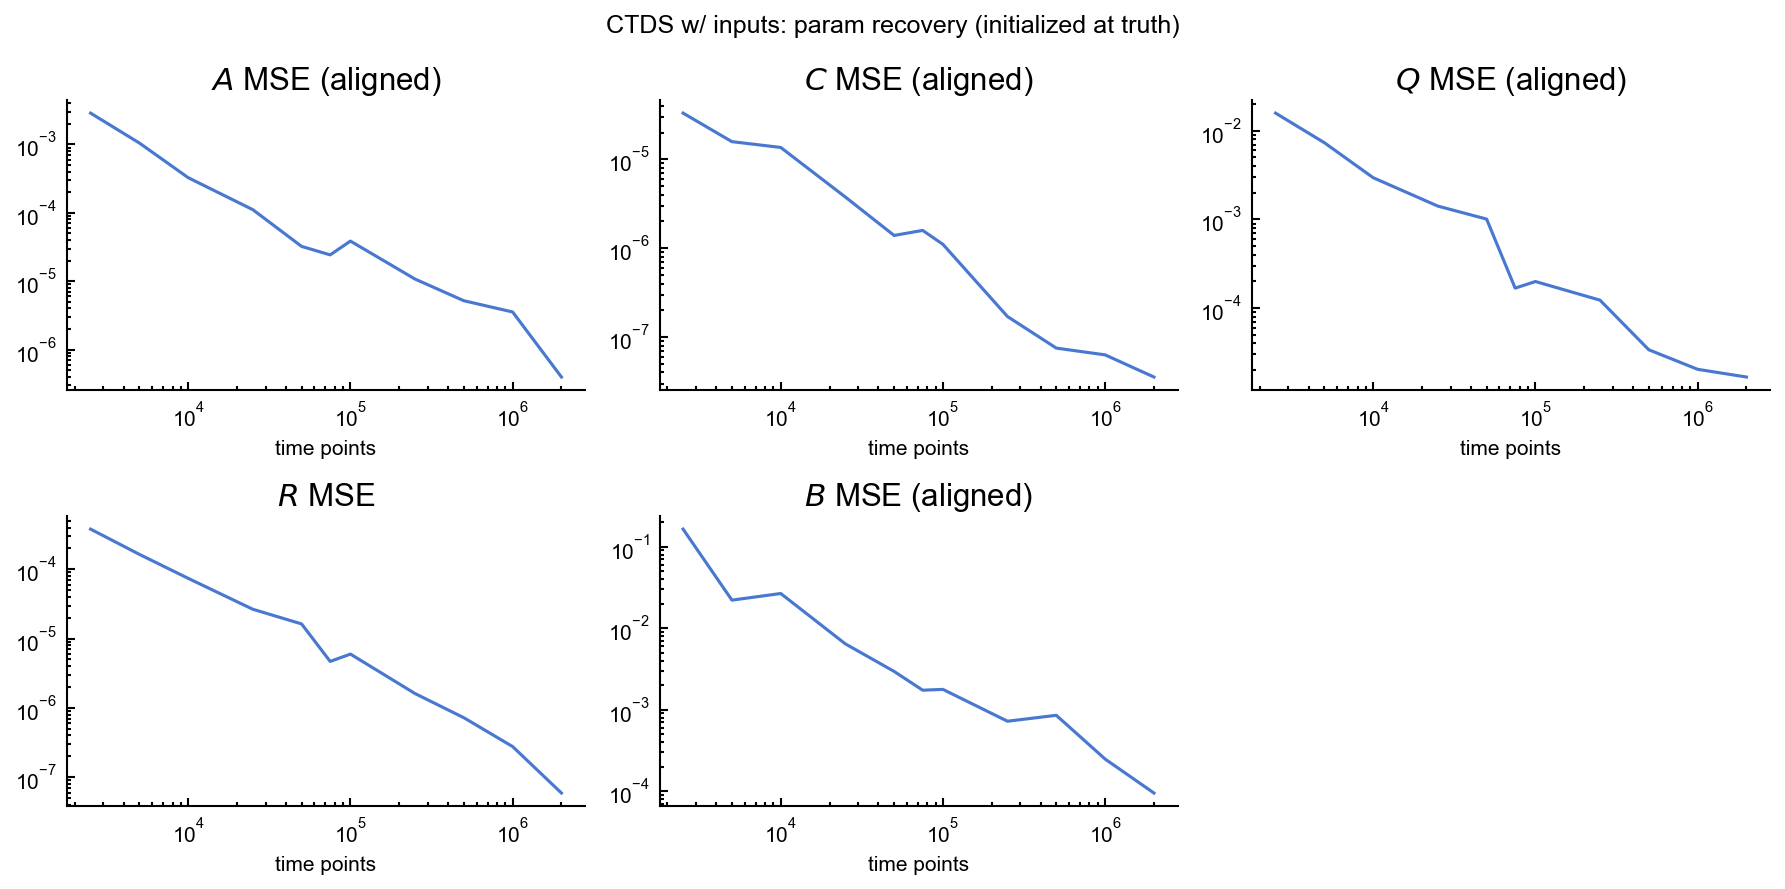

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
titles = ['$A$ MSE (aligned)', '$C$ MSE (aligned)', '$Q$ MSE (aligned)',
          '$R$ MSE', '$B$ MSE (aligned)', '']
losses = [A_loss, C_loss, Q_loss, R_loss, B_loss, None]

for ax, title, loss in zip(axes.flat, titles, losses):
    if loss is None:
        ax.set_visible(False)
        continue
    ax.plot(T * np.array(trial_list), loss)
    ax.set_title(title)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('time points')

fig.suptitle('CTDS w/ inputs: param recovery (initialized at truth)')
fig.tight_layout()

In [6]:
from pillow_lab_rotation.plotting import plot_ctds_matrices

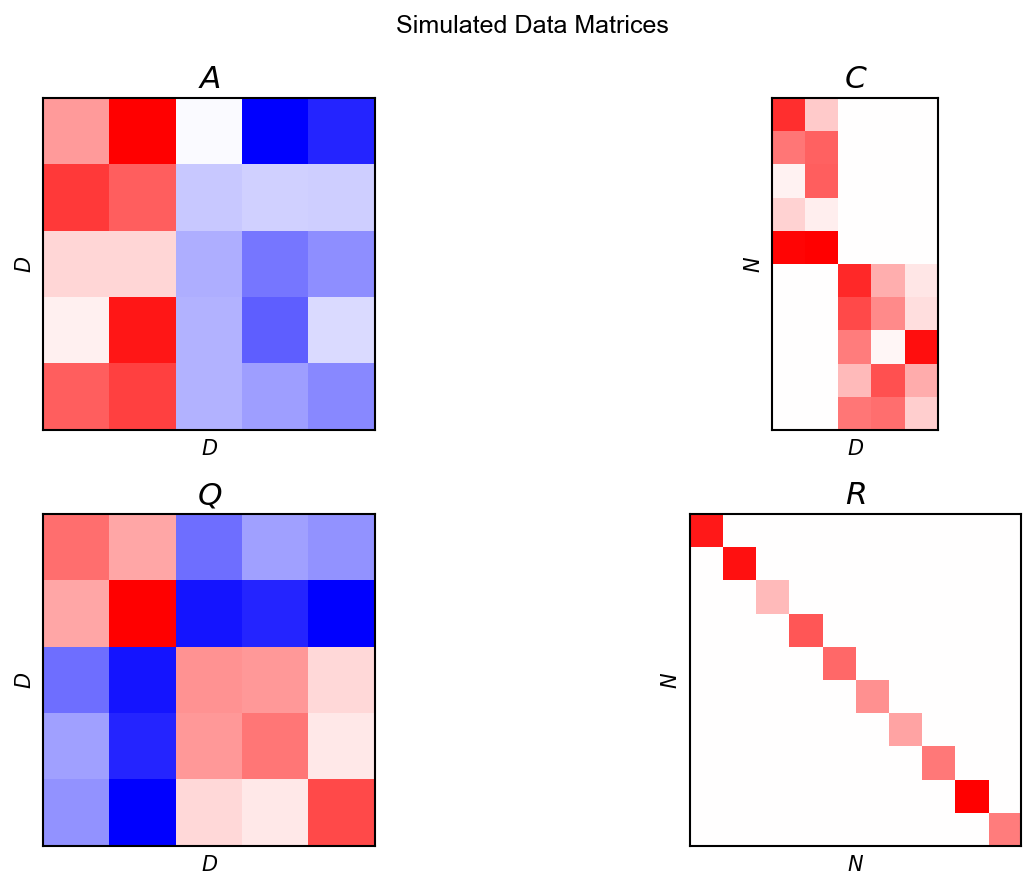

In [7]:
plot_ctds_matrices(
    ctds.A,
    ctds.C,
    ctds.Q,
    ctds.R
)

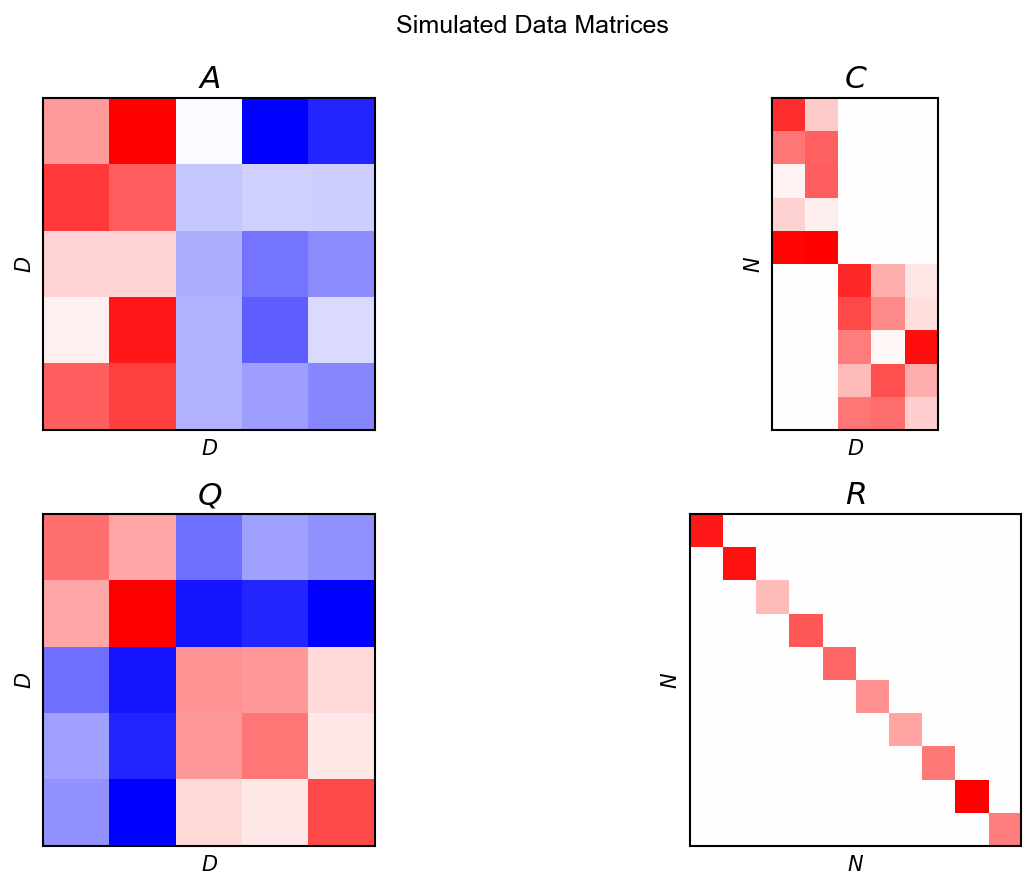

In [8]:
plot_ctds_matrices(
    simulation.A,
    simulation.C,
    simulation.Q,
    simulation.R
)

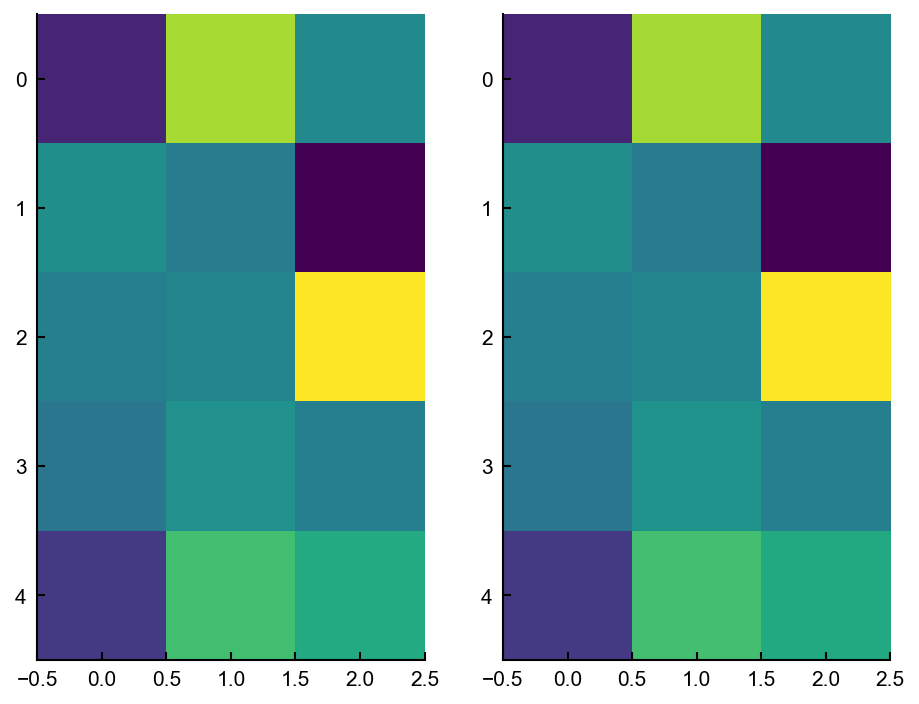

In [10]:
fig, ax = plt.subplots(1, 2)
ax[0].imshow(simulation.B)
ax[1].imshow(ctds.B)